In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from imblearn.combine import SMOTEENN

from pycaret.regression import *
from pycaret.internal.preprocess.transformers import TransformerWrapper

import joblib # For store the PowerTrasnformers

### Innits


In [68]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [69]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

data_36 = data_24_25_test[data_24_25_test['event'] == 36]
data_37 = data_24_25_test[data_24_25_test['event'] == 37]
data_38 = data_24_25_test[data_24_25_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [70]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Goals


## Def


In [71]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    1247
0.079771       1
0.010171       1
0.083317       1
0.013697       1
            ... 
0.088027       1
0.039602       1
0.016649       1
0.061770       1
0.048601       1
Name: count, Length: 742, dtype: int64


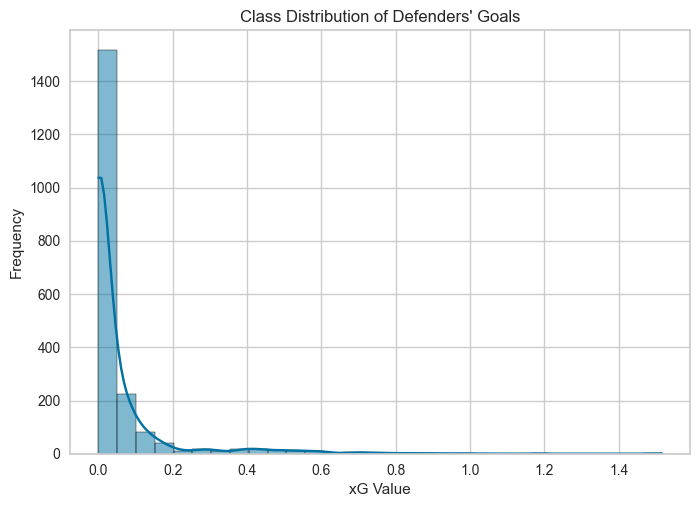

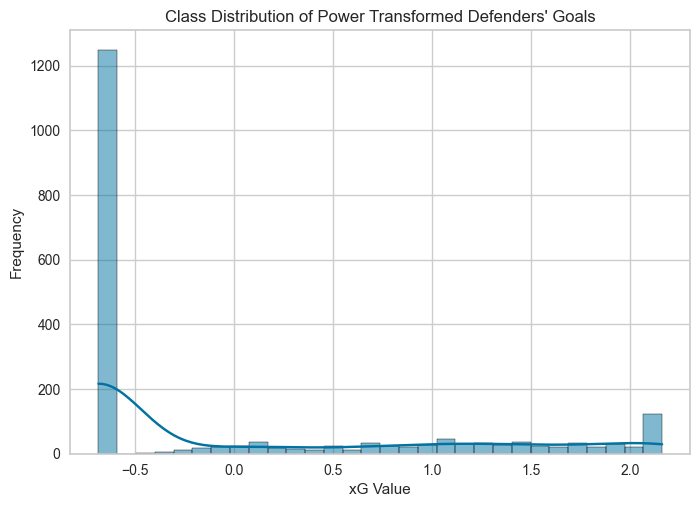

In [72]:
## TODO: XG PER 90????
def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xg.fit(def_xg_data[['xG']])
joblib.dump(pt_def_xg, './models/pt_def_xg.pkl')  # Save fitted transformer

def_xg_data['xG'] = pt_def_xg.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Power Transformed Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [73]:
def_xg_data

,xG,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,percenatge_net_transfers,ict_index,influence,...,xG_5,xA_5,assists_x_5,assists_y_5,key_passes_5,npg_5,npxG_5,xGChain_5,xGBuildup_5,xP_5
0,-0.686268,0.280,0.254,0.465,True,3,3,-0.531612,2.7,26.4,...,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.20,0.20,0.58
1,1.193559,0.561,0.227,0.212,True,2,3,-0.850263,2.2,4.2,...,0.04,0.09,0.0,0.0,0.8,0.0,0.04,0.35,0.24,0.26
2,-0.686268,0.585,0.226,0.190,True,1,2,0.740046,6.4,30.8,...,0.01,0.02,0.0,0.0,0.4,0.0,0.01,0.17,0.17,0.64
3,-0.686268,0.291,0.278,0.430,True,4,2,0.753496,1.1,10.0,...,0.01,0.26,0.0,0.0,0.8,0.0,0.01,0.31,0.18,1.36
4,-0.686268,0.378,0.296,0.326,False,2,3,-0.174677,1.9,18.6,...,0.01,0.26,0.0,0.0,0.8,0.0,0.01,0.32,0.19,2.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1983,-0.686268,0.355,0.290,0.355,True,4,4,0.785523,2.4,23.0,...,0.03,0.17,0.2,0.2,0.8,0.0,0.03,0.39,0.23,3.36
1984,-0.686268,0.693,0.201,0.106,False,4,5,0.301482,1.8,13.6,...,0.02,0.17,0.2,0.2,0.8,0.0,0.02,0.42,0.26,3.66
1985,-0.686268,0.554,0.248,0.198,True,2,4,0.538888,0.3,2.2,...,0.02,0.17,0.2,0.2,0.8,0.0,0.02,0.37,0.22,3.70
1986,0.873878,0.696,0.199,0.105,False,4,4,-0.728543,2.6,16.2,...,0.01,0.13,0.2,0.2,0.4,0.0,0.01,0.24,0.10,3.64


In [74]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4579
[LightGBM] [Info] Number of data points in the train set: 1590, number of used features: 71
[LightGBM] [Info] Start training from score -0.019948


,Description,Value
0,Session id,6799
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1988, 93)"
4,Transformed data shape,"(1988, 19)"
5,Transformed train set shape,"(1590, 19)"
6,Transformed test set shape,"(398, 19)"
7,Numeric features,91
8,Rows with missing values,0.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3182,0.2908,0.5376,0.7002,0.2405,1.9140,0.7440
rf,Random Forest Regressor,0.3281,0.3069,0.5525,0.6833,0.2460,1.9843,1.1310
lightgbm,Light Gradient Boosting Machine,0.3500,0.3149,0.5596,0.6754,0.2462,2.1755,0.7080
gbr,Gradient Boosting Regressor,0.3536,0.3052,0.5510,0.6847,0.2502,1.9795,0.9660
xgboost,Extreme Gradient Boosting,0.3544,0.3311,0.5732,0.6591,0.2520,2.1852,0.4980
dt,Decision Tree Regressor,0.3955,0.5761,0.7554,0.4066,0.2651,2.9101,0.5910
ada,AdaBoost Regressor,0.4262,0.3484,0.5880,0.6410,0.2606,1.8669,0.5880
huber,Huber Regressor,0.4361,0.4806,0.6921,0.5029,0.3217,1.5269,0.6510
knn,K Neighbors Regressor,0.4509,0.4797,0.6902,0.5040,0.3022,2.4027,0.6350
lr,Linear Regression,0.5015,0.4528,0.6720,0.5316,0.3472,1.5637,2.4070


ExtraTreesRegressor(n_jobs=-1, random_state=6799)

In [75]:
evaluate_model(base_def_xg_best)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

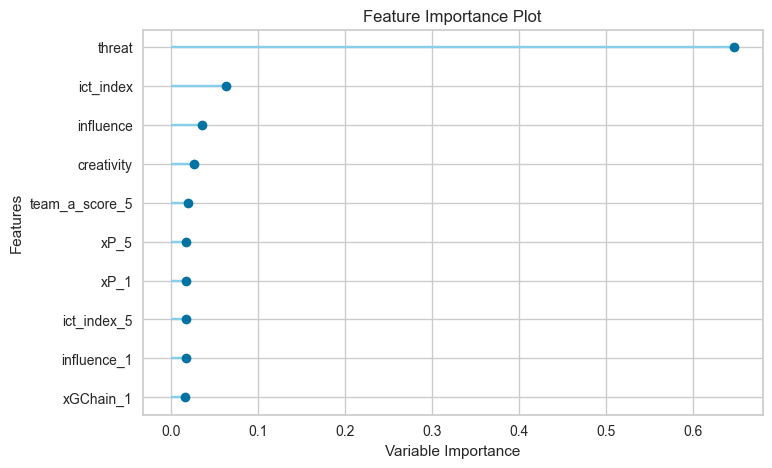

In [76]:
# plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
# plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Tune Model


In [77]:
def_xg_tuned = tune_model(base_def_xg_best, optimize='MAE')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,21:12:24
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Extra Trees Regressor


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3208,0.2973,0.5453,0.6744,0.2444,1.8261
1,0.2855,0.3188,0.5646,0.6825,0.1955,0.6116
2,0.2881,0.3115,0.5581,0.6706,0.2500,0.9086
3,0.3556,0.3714,0.6094,0.6266,0.2430,0.8781
4,0.3631,0.3718,0.6098,0.6655,0.2562,2.5323
5,0.3551,0.4316,0.6569,0.5900,0.2323,0.6289
6,0.3152,0.2935,0.5417,0.6745,0.2458,0.7735
7,0.2900,0.3342,0.5781,0.6599,0.2114,0.7328
8,0.3080,0.2997,0.5475,0.6453,0.2278,2.1671


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [78]:
# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, './models/def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [79]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    810
0.761169      3
0.147185      1
0.123450      1
0.450628      1
           ... 
0.151355      1
0.050403      1
0.062555      1
0.040897      1
0.036180      1
Name: count, Length: 1384, dtype: int64


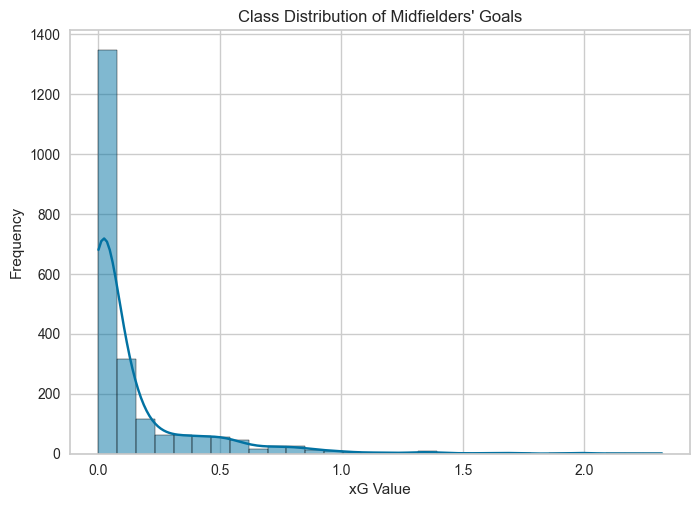

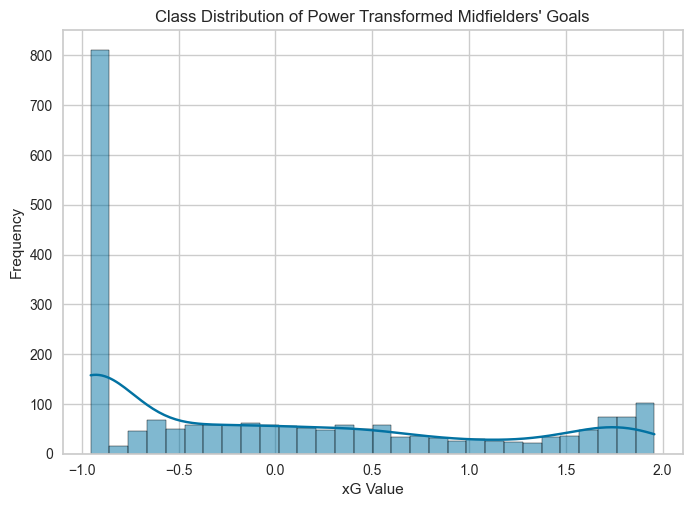

In [80]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xg.fit(mid_xg_data[['xG']])
joblib.dump(pt_mid_xg, './models/pt_mid_xg.pkl')  # Save fitted transformer

mid_xg_data['xG'] = pt_mid_xg.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Power Transformed Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [81]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE')
base_mid_xg_best

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5595
[LightGBM] [Info] Number of data points in the train set: 1756, number of used features: 68
[LightGBM] [Info] Start training from score -0.004331


,Description,Value
0,Session id,6621
1,Target,xG
2,Target type,Regression
3,Original data shape,"(2195, 93)"
4,Transformed data shape,"(2195, 19)"
5,Transformed train set shape,"(1756, 19)"
6,Transformed test set shape,"(439, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3588,0.2782,0.5260,0.7183,0.2528,2.4899,1.3950
rf,Random Forest Regressor,0.3609,0.2811,0.5290,0.7150,0.2596,2.4934,1.7630
gbr,Gradient Boosting Regressor,0.3735,0.2766,0.5245,0.7195,0.2572,3.3699,1.2640
lightgbm,Light Gradient Boosting Machine,0.3806,0.2942,0.5409,0.7020,0.2642,2.9215,0.9440
xgboost,Extreme Gradient Boosting,0.3915,0.3156,0.5604,0.6803,0.2652,2.8205,0.9910
ada,AdaBoost Regressor,0.4403,0.3193,0.5640,0.6752,0.2808,3.2622,0.9740
knn,K Neighbors Regressor,0.4426,0.3685,0.6047,0.6272,0.2815,2.2171,1.1160
huber,Huber Regressor,0.4592,0.4046,0.6335,0.5917,0.2900,1.9799,0.6970
dt,Decision Tree Regressor,0.4737,0.5308,0.7271,0.4591,0.3096,2.8283,2.0090
lar,Least Angle Regression,0.4744,0.3825,0.6162,0.6139,0.3031,1.8253,0.8060


ExtraTreesRegressor(n_jobs=-1, random_state=6621)

In [82]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

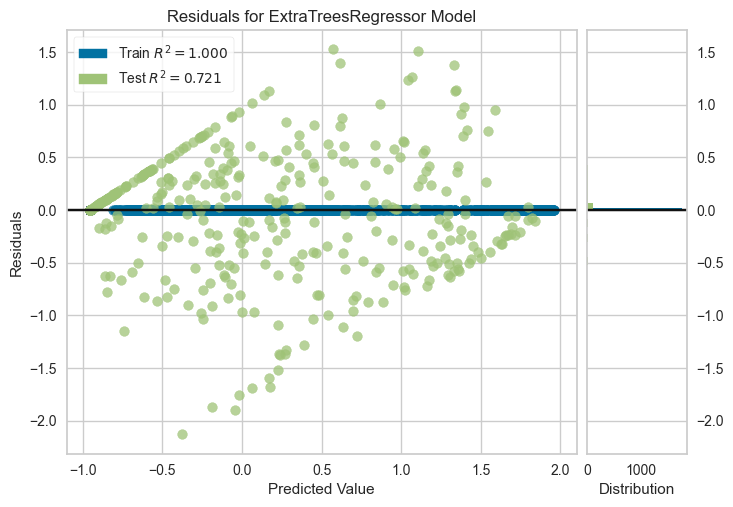

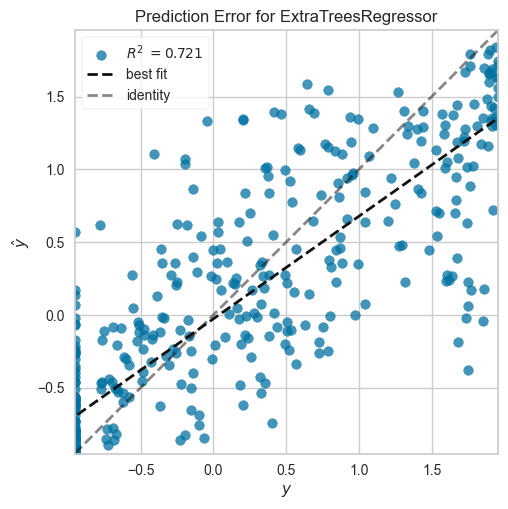

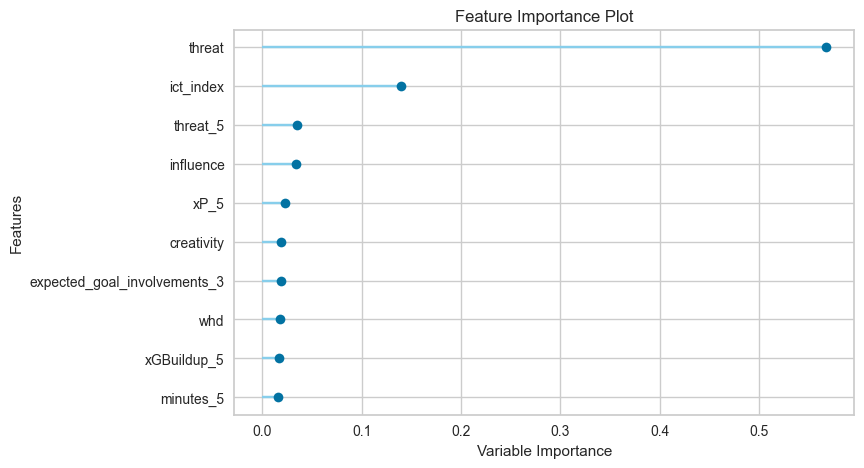

In [83]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Tune Model


In [84]:
mid_xg_tuned = tune_model(base_mid_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3895,0.3227,0.5680,0.6770,0.2817,5.6579
1,0.4261,0.3545,0.5954,0.6336,0.2854,1.3441
2,0.3196,0.2564,0.5064,0.7371,0.2277,1.0059
3,0.3123,0.2038,0.4515,0.7921,0.2353,5.6083
4,0.3668,0.2905,0.5390,0.7155,0.2665,1.2378
5,0.3356,0.2793,0.5285,0.7392,0.2416,0.6928
6,0.3134,0.2000,0.4472,0.7649,0.2284,1.3948
7,0.4120,0.3428,0.5854,0.6791,0.2930,1.8174
8,0.3587,0.2970,0.5449,0.6998,0.2507,4.1482


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [85]:
mid_xg_final_model = finalize_model(base_mid_xg_best)
save_model(mid_xg_final_model, './models/mid_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## For


xG
0.000000    88
0.761169     5
0.809630     1
0.019979     1
0.124873     1
            ..
0.131738     1
1.595947     1
0.108552     1
0.430259     1
0.326243     1
Name: count, Length: 406, dtype: int64


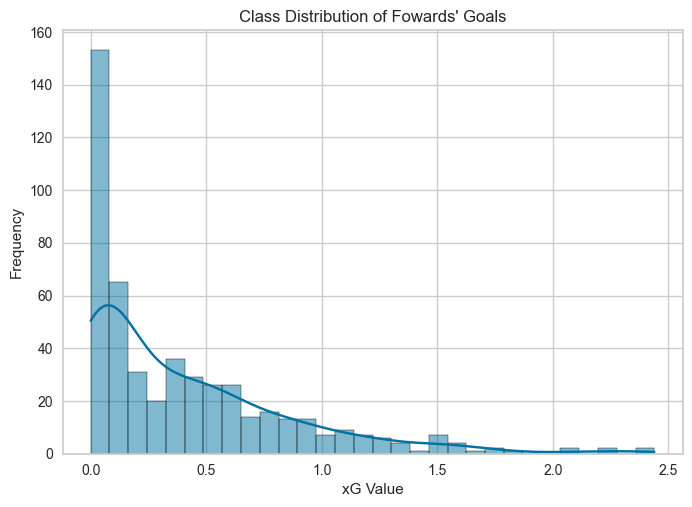

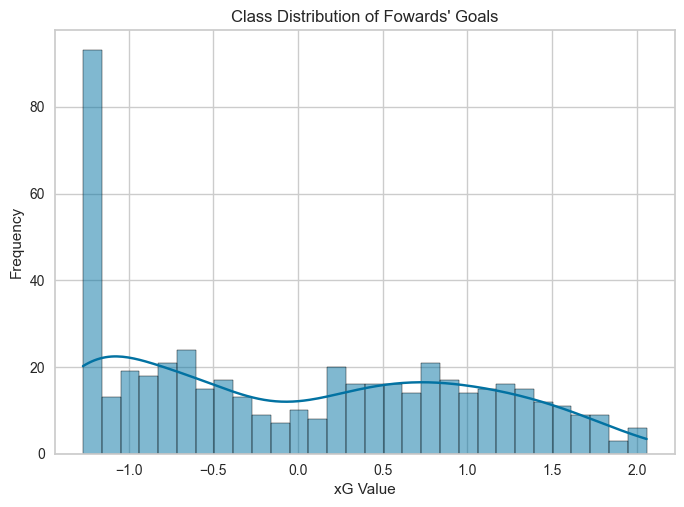

In [86]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_xg_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_xg_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_xg_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xg.fit(fwd_xg_data[['xG']])
joblib.dump(pt_fwd_xg, './models/pt_fwd_xg.pkl')  # Save fitted transformer

fwd_xg_data['xG'] = pt_fwd_xg.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2651
[LightGBM] [Info] Number of data points in the train set: 397, number of used features: 64
[LightGBM] [Info] Start training from score -0.020250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Description,Value
0,Session id,8208
1,Target,xG
2,Target type,Regression
3,Original data shape,"(497, 93)"
4,Transformed data shape,"(497, 19)"
5,Transformed train set shape,"(397, 19)"
6,Transformed test set shape,"(100, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.4224,0.3163,0.5610,0.6712,0.2686,1.9061,0.7090
rf,Random Forest Regressor,0.4271,0.3187,0.5629,0.6694,0.2687,2.6413,0.9230
gbr,Gradient Boosting Regressor,0.4295,0.3208,0.5643,0.6649,0.2594,1.2163,1.0970
knn,K Neighbors Regressor,0.4355,0.3317,0.5717,0.6525,0.2586,9.8376,0.4980
lightgbm,Light Gradient Boosting Machine,0.4509,0.3406,0.5820,0.6468,0.2582,2.0594,0.4110
br,Bayesian Ridge,0.4652,0.3292,0.5727,0.6604,0.2762,11.1973,0.3640
huber,Huber Regressor,0.4707,0.3508,0.5904,0.6362,0.2733,10.9214,0.4920
en,Elastic Net,0.4708,0.3307,0.5744,0.6588,0.2784,10.9069,0.8700
ridge,Ridge Regression,0.4719,0.3358,0.5782,0.6537,0.2729,12.1612,0.4140
lar,Least Angle Regression,0.4741,0.3413,0.5830,0.6483,0.2742,12.4220,0.5370


ExtraTreesRegressor(n_jobs=-1, random_state=8208)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


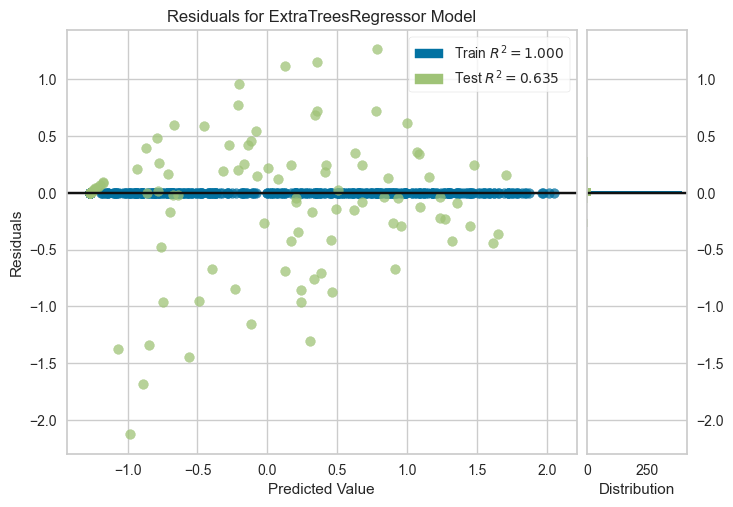

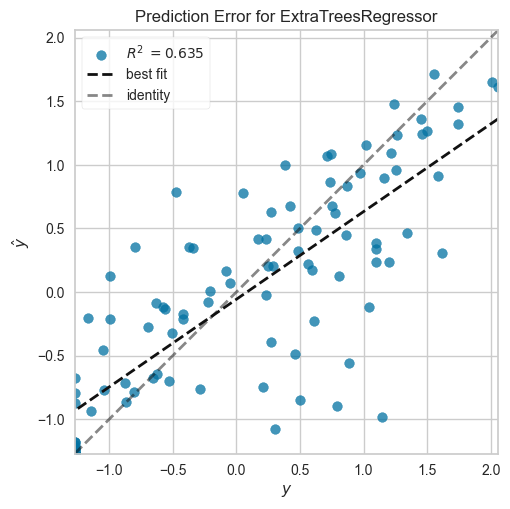

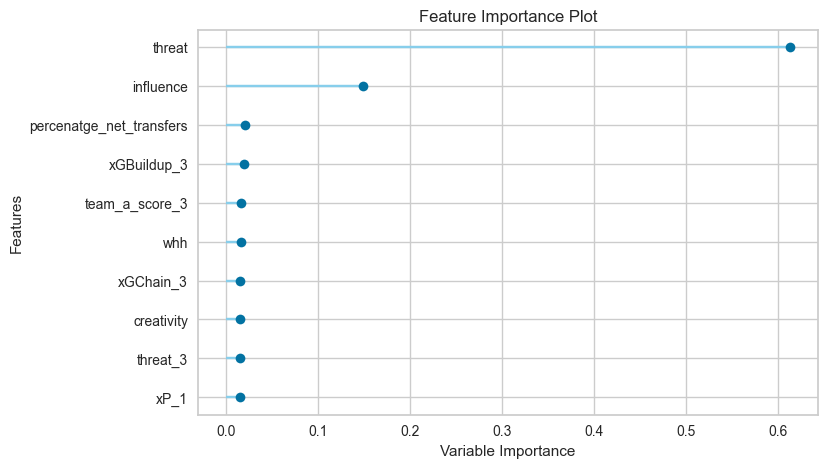

In [87]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Tune Model


In [88]:
tuned_fwd_xg_model = tune_model(base_fwd_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6660,0.5718,0.7562,0.3956,0.4117,0.9126
1,0.7228,0.6508,0.8067,0.4211,0.4609,0.7647
2,0.6720,0.5459,0.7388,0.4129,0.4061,3.9742
3,0.7642,0.7499,0.8660,0.3147,0.4873,0.8970
4,0.7216,0.6557,0.8097,0.3012,0.4836,0.8545
5,0.6984,0.5794,0.7612,0.4858,0.4118,1.0483
6,0.6551,0.5357,0.7319,0.3645,0.4285,0.8097
7,0.7472,0.7054,0.8399,0.3893,0.4769,0.8173
8,0.6357,0.5013,0.7081,0.3999,0.4146,0.8087


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [89]:
fwd_xg_final_model = finalize_model(tuned_fwd_xg_model)
save_model(fwd_xg_final_model, './models/fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

# Assists


In [90]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## Def


xA
0.000000    1305
0.242512       1
0.315964       1
0.083439       1
0.464353       1
            ... 
0.020245       1
0.018523       1
0.042506       1
0.078929       1
0.549479       1
Name: count, Length: 684, dtype: int64


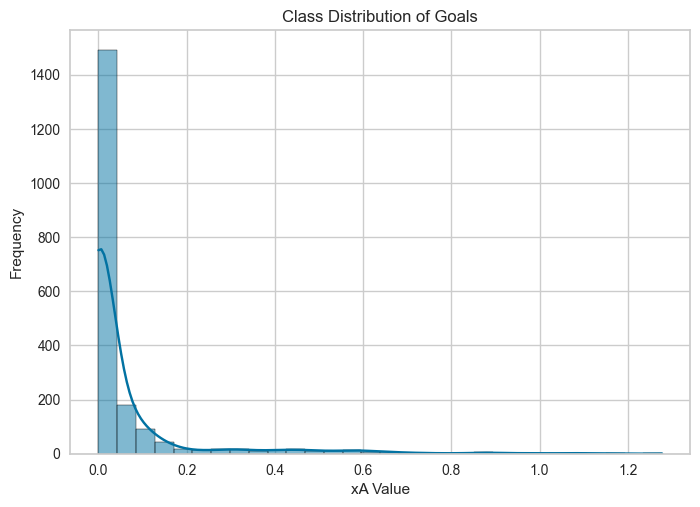

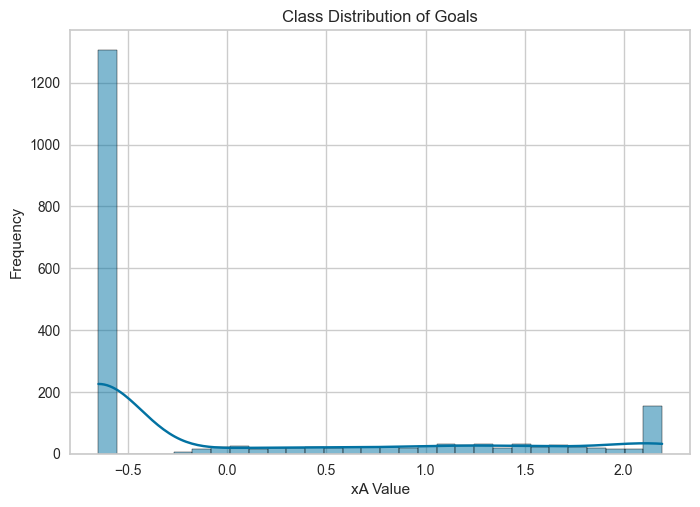

In [91]:
def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[xa_features]
def_xa_data_tar = def_xa_data_tar[xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(def_xa_data['xA'].value_counts())

sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xa.fit(def_xa_data[['xA']])
joblib.dump(pt_def_xa, './models/pt_def_xa.pkl')  # Save fitted transformer

def_xa_data['xA'] = pt_def_xa.transform(def_xa_data[['xA']])


sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4884
[LightGBM] [Info] Number of data points in the train set: 1590, number of used features: 63
[LightGBM] [Info] Start training from score 0.000244
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Description,Value
0,Session id,1940
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1988, 76)"
4,Transformed data shape,"(1988, 16)"
5,Transformed train set shape,"(1590, 16)"
6,Transformed test set shape,"(398, 16)"
7,Numeric features,74
8,Rows with missing values,0.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.2121,0.1918,0.4365,0.8059,0.1996,1.2601,1.0890
et,Extra Trees Regressor,0.2165,0.1901,0.4347,0.8076,0.2013,1.2077,0.7380
ada,AdaBoost Regressor,0.2289,0.2025,0.4490,0.7942,0.2032,1.2876,0.4800
gbr,Gradient Boosting Regressor,0.2328,0.1998,0.4458,0.7966,0.2049,1.2560,1.3430
lightgbm,Light Gradient Boosting Machine,0.2382,0.2158,0.4631,0.7818,0.2153,1.3219,1.4180
xgboost,Extreme Gradient Boosting,0.2414,0.2183,0.4652,0.7793,0.2158,1.3319,1.2220
knn,K Neighbors Regressor,0.2565,0.2471,0.4963,0.7490,0.2287,1.0070,0.4030
dt,Decision Tree Regressor,0.2726,0.3406,0.5817,0.6541,0.2628,1.4800,0.8240
huber,Huber Regressor,0.3432,0.3650,0.6002,0.6333,0.2927,0.6341,0.3770
omp,Orthogonal Matching Pursuit,0.3881,0.3529,0.5910,0.6448,0.2924,0.7841,0.5750


RandomForestRegressor(n_jobs=-1, random_state=1940)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


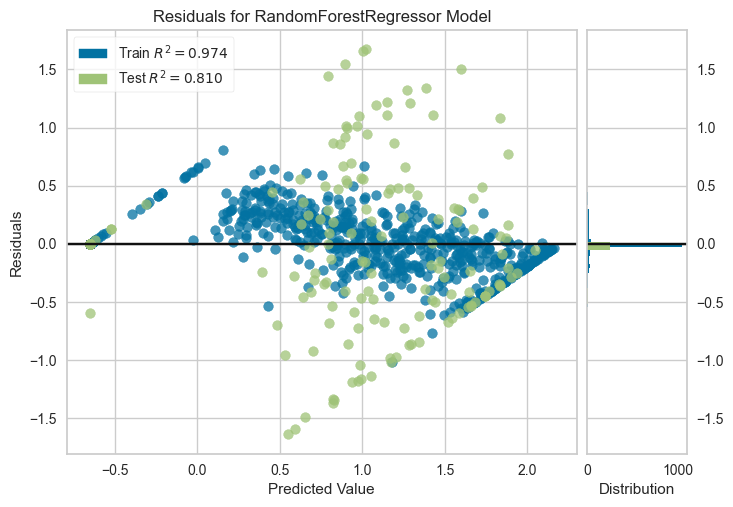

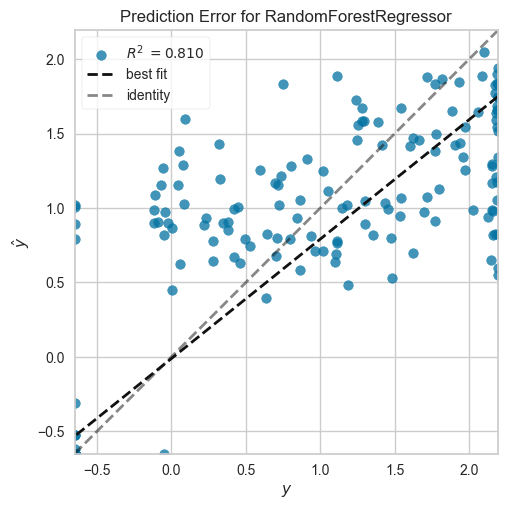

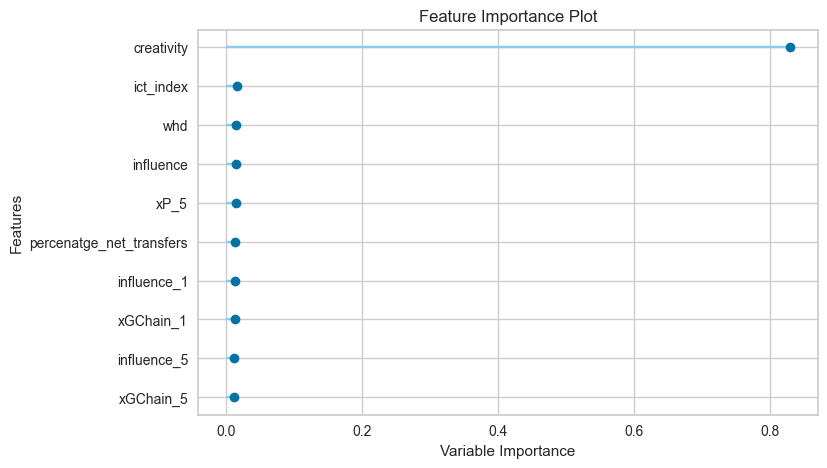

In [92]:
base_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xa_best = base_def_xa_model.compare_models(sort='MAE', n_select=1)
print(base_def_xa_best)

print('Évaluate the model...')
evaluate_model(base_def_xa_best)

print('Plots...')
plot_model(base_def_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xa_best, plot='error')          # Prediction error plot
plot_model(base_def_xa_best, plot='feature')        # Feature importance



### Tune Model


In [93]:
def_xa_tuned = tune_model(base_def_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2311,0.2163,0.4650,0.7924,0.1908,0.3739
1,0.1950,0.1521,0.3900,0.8427,0.1829,0.8087
2,0.2494,0.2248,0.4741,0.7893,0.2276,1.5694
3,0.2100,0.1801,0.4244,0.8236,0.1990,0.8690
4,0.2034,0.1916,0.4377,0.7815,0.2068,2.0541
5,0.1652,0.1494,0.3865,0.8392,0.1632,0.4370
6,0.2184,0.2105,0.4588,0.7824,0.2028,0.7198
7,0.2065,0.1864,0.4317,0.7720,0.1963,1.0125
8,0.2407,0.2195,0.4685,0.8027,0.1971,1.1956


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [94]:
def_xa_final_model = finalize_model(base_def_xa_best)
save_model(def_xa_final_model, './models/def_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## Mid


xA
0.000000    932
0.977940      1
0.028029      1
0.226455      1
0.664029      1
           ... 
0.154320      1
0.064043      1
0.649635      1
0.058068      1
0.043413      1
Name: count, Length: 1264, dtype: int64


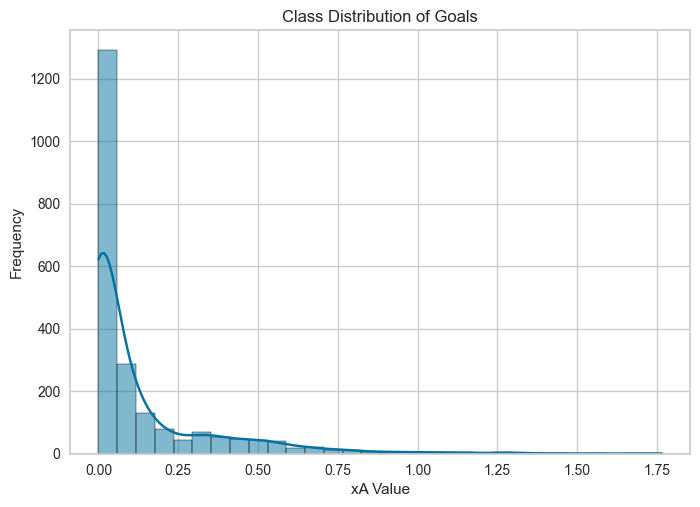

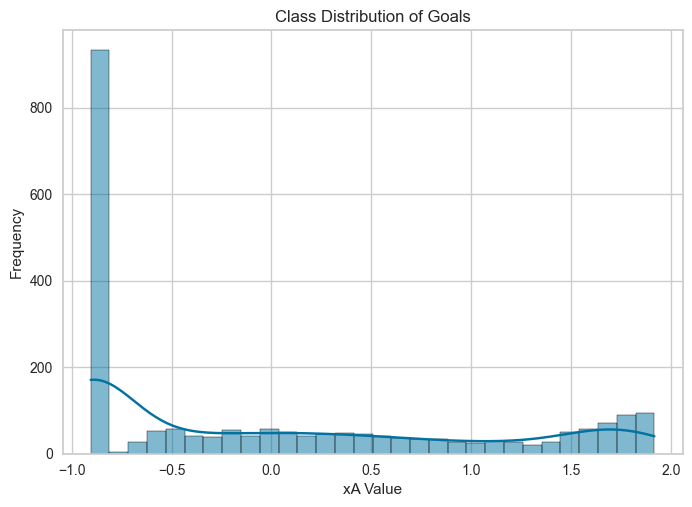

In [95]:

mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[xa_features]
mid_xa_data_tar = mid_xa_data_tar[xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(mid_xa_data['xA'].value_counts())

sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xa.fit(mid_xa_data[['xA']])
joblib.dump(pt_mid_xa, './models/pt_mid_xa.pkl')  # Save fitted transformer

mid_xa_data['xA'] = pt_mid_xa.transform(mid_xa_data[['xA']])


sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001715 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6207
[LightGBM] [Info] Number of data points in the train set: 1756, number of used features: 65
[LightGBM] [Info] Start training from score 0.005311


,Description,Value
0,Session id,4251
1,Target,xA
2,Target type,Regression
3,Original data shape,"(2195, 76)"
4,Transformed data shape,"(2195, 16)"
5,Transformed train set shape,"(1756, 16)"
6,Transformed test set shape,"(439, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3357,0.2818,0.5283,0.7150,0.2570,1.4915,1.4300
et,Extra Trees Regressor,0.3377,0.2784,0.5256,0.7186,0.2581,1.4464,0.9200
gbr,Gradient Boosting Regressor,0.3476,0.2776,0.5242,0.7195,0.2533,1.3663,1.0290
lightgbm,Light Gradient Boosting Machine,0.3594,0.3019,0.5464,0.6945,0.2605,1.5899,0.8850
ada,AdaBoost Regressor,0.3641,0.2975,0.5432,0.6986,0.2355,1.6036,0.5880
xgboost,Extreme Gradient Boosting,0.3753,0.3249,0.5668,0.6715,0.2605,1.4849,1.3210
knn,K Neighbors Regressor,0.3891,0.3514,0.5901,0.6456,0.2763,1.3648,0.5690
huber,Huber Regressor,0.4197,0.3962,0.6270,0.6010,0.2944,1.0280,0.6420
dt,Decision Tree Regressor,0.4372,0.5232,0.7184,0.4728,0.3152,2.6167,0.5910
lr,Linear Regression,0.4528,0.3786,0.6133,0.6185,0.3085,1.0701,0.4530


RandomForestRegressor(n_jobs=-1, random_state=4251)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


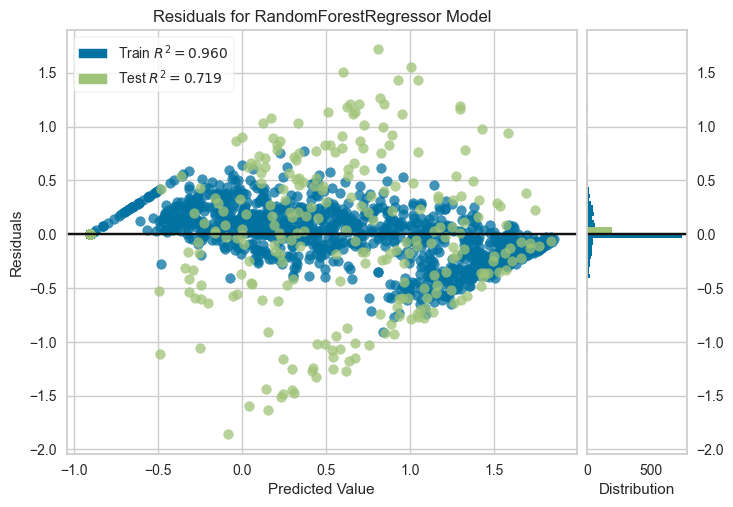

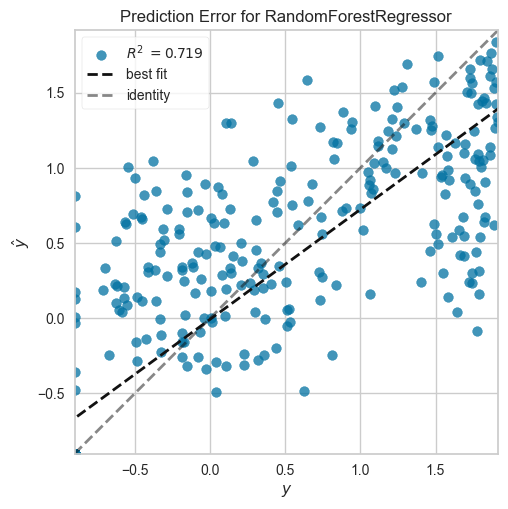

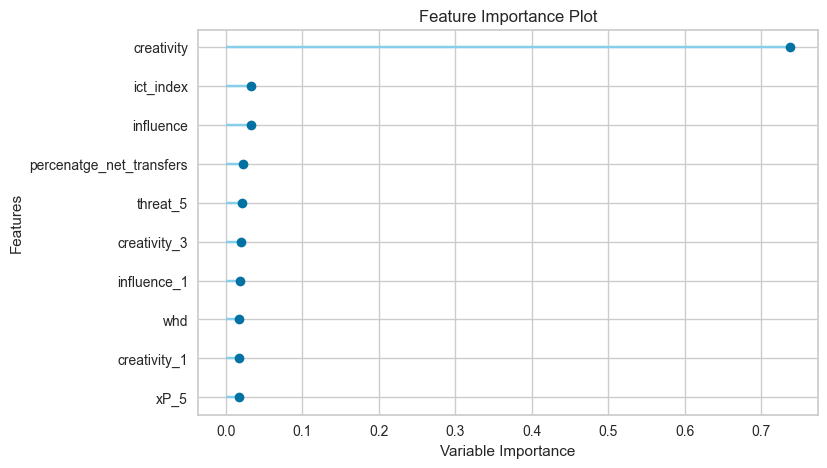

In [96]:
base_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xa_best = base_mid_xa_model.compare_models(sort='MAE', n_select=1)
print(base_mid_xa_best)

print('Évaluate the model...')
evaluate_model(base_mid_xa_best)

print('Plots...')
plot_model(base_mid_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xa_best, plot='error')          # Prediction error plot
plot_model(base_mid_xa_best, plot='feature')        # Feature importance



### Tune model


In [97]:
mid_xa_tuned = tune_model(base_mid_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2648,0.1847,0.4297,0.8108,0.2077,0.7175
1,0.2958,0.2528,0.5028,0.7494,0.2507,0.7786
2,0.3580,0.3203,0.5659,0.6338,0.2631,0.7920
3,0.3308,0.2652,0.5150,0.7310,0.2741,0.8432
4,0.3892,0.3505,0.5920,0.6251,0.2929,2.4753
5,0.3699,0.3267,0.5716,0.7009,0.2670,1.0134
6,0.4103,0.3727,0.6105,0.6443,0.2930,2.5652
7,0.3360,0.2574,0.5073,0.7357,0.2541,0.9563
8,0.3458,0.2972,0.5452,0.7139,0.2584,2.2054


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [98]:
mid_xa_final_model = finalize_model(base_mid_xa_best)
save_model(mid_xa_final_model, './models/mid_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## For


xA
0.000000    248
0.136433      1
0.103492      1
0.323796      1
0.705970      1
           ... 
0.313491      1
0.077780      1
0.062962      1
0.087249      1
0.048869      1
Name: count, Length: 250, dtype: int64


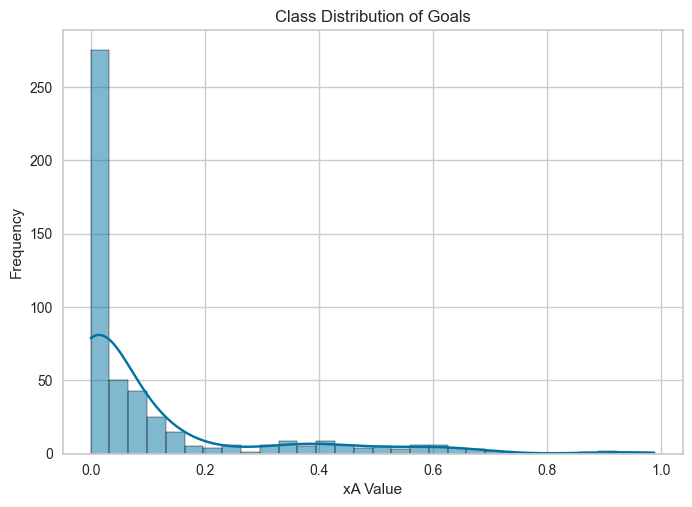

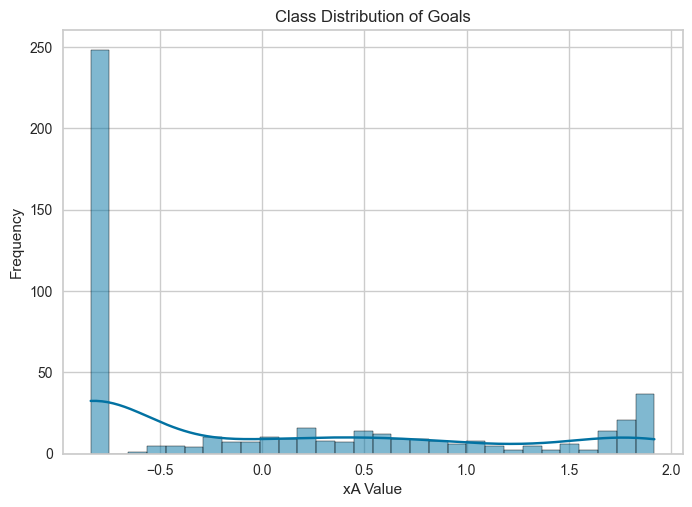

In [99]:

fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)



print(fwd_xa_data['xA'].value_counts())

sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xa.fit(fwd_xa_data[['xA']])
joblib.dump(pt_fwd_xa, './models/pt_fwd_xa.pkl')  # Save fitted transformer

fwd_xa_data['xA'] = pt_fwd_xa.transform(fwd_xa_data[['xA']])


sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012986 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3440
[LightGBM] [Info] Number of data points in the train set: 397, number of used features: 66
[LightGBM] [Info] Start training from score 0.045268
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,Description,Value
0,Session id,5028
1,Target,xA
2,Target type,Regression
3,Original data shape,"(497, 76)"
4,Transformed data shape,"(497, 16)"
5,Transformed train set shape,"(397, 16)"
6,Transformed test set shape,"(100, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3066,0.2559,0.5013,0.7420,0.2279,0.9400,0.4680
rf,Random Forest Regressor,0.3078,0.2629,0.5095,0.7335,0.2335,1.0032,0.4630
xgboost,Extreme Gradient Boosting,0.3254,0.2938,0.5337,0.7039,0.2477,0.9420,0.5680
lightgbm,Light Gradient Boosting Machine,0.3387,0.2850,0.5281,0.7105,0.2403,0.9238,0.5400
gbr,Gradient Boosting Regressor,0.3454,0.2763,0.5212,0.7217,0.2441,0.9499,0.4140
ada,AdaBoost Regressor,0.3700,0.2910,0.5355,0.7057,0.2456,1.0627,0.2890
huber,Huber Regressor,0.4295,0.3951,0.6246,0.6050,0.3135,0.7070,0.4950
dt,Decision Tree Regressor,0.4386,0.5655,0.7459,0.4297,0.3388,1.4607,0.5830
ridge,Ridge Regression,0.4439,0.3736,0.6082,0.6256,0.3119,0.7590,0.4430
lr,Linear Regression,0.4439,0.3741,0.6088,0.6249,0.3111,0.7649,0.4880


ExtraTreesRegressor(n_jobs=-1, random_state=5028)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


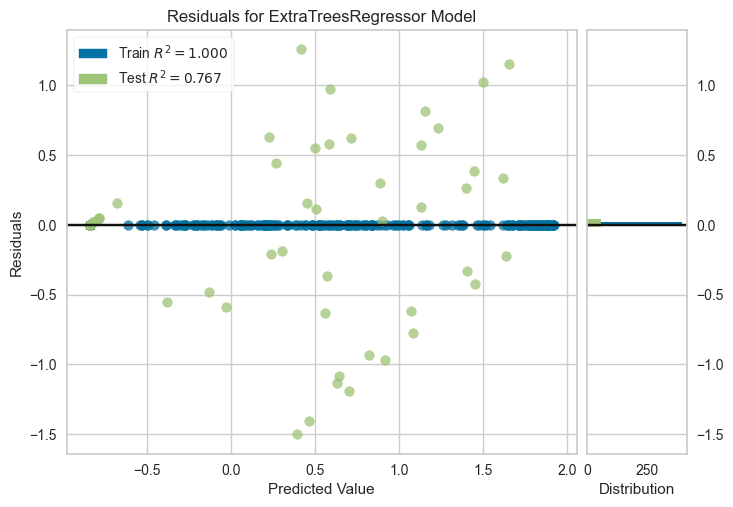

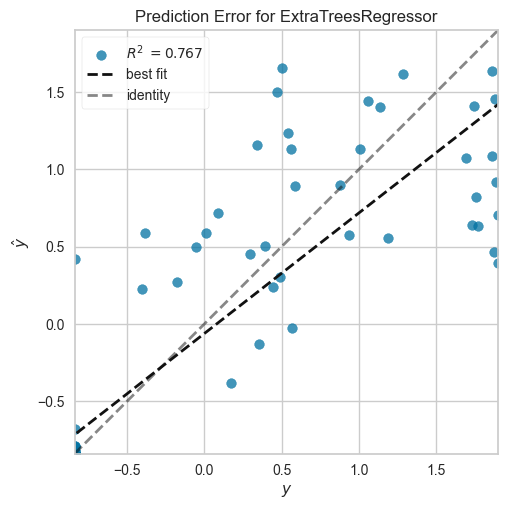

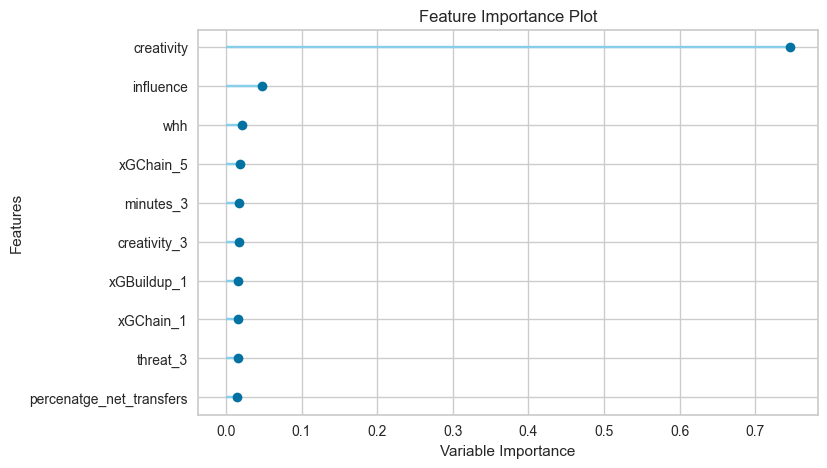

In [100]:
base_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xa_best = base_fwd_xa_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xa_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xa_best)

print('Plots...')
plot_model(base_fwd_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xa_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xa_best, plot='feature')        # Feature importance

### Tune model


In [101]:
fwd_xa_tuned = tune_model(base_fwd_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4114,0.3553,0.5961,0.6889,0.3084,0.8309
1,0.2940,0.2264,0.4758,0.8006,0.2199,0.4391
2,0.4662,0.4116,0.6415,0.6637,0.3016,0.6104
3,0.3462,0.3261,0.5711,0.6630,0.2745,0.5912
4,0.3209,0.2600,0.5099,0.7147,0.2659,0.7752
5,0.3150,0.2457,0.4957,0.7248,0.2650,0.6619
6,0.2674,0.2361,0.4859,0.7136,0.2314,1.3379
7,0.2440,0.1275,0.3571,0.8767,0.1543,0.3495
8,0.2566,0.1629,0.4036,0.8197,0.2050,1.2287


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [102]:
fwd_xa_final_model = finalize_model(base_fwd_xa_best)
save_model(fwd_xa_final_model, './models/fwd_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


# Saves


## GK


saves
2     124
3      87
1      79
4      74
5      51
0      34
6      26
7      16
8       7
13      1
9       1
10      1
Name: count, dtype: int64


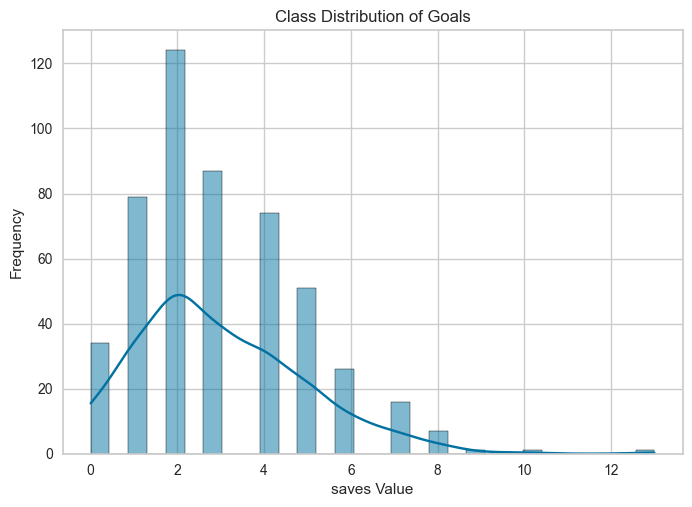

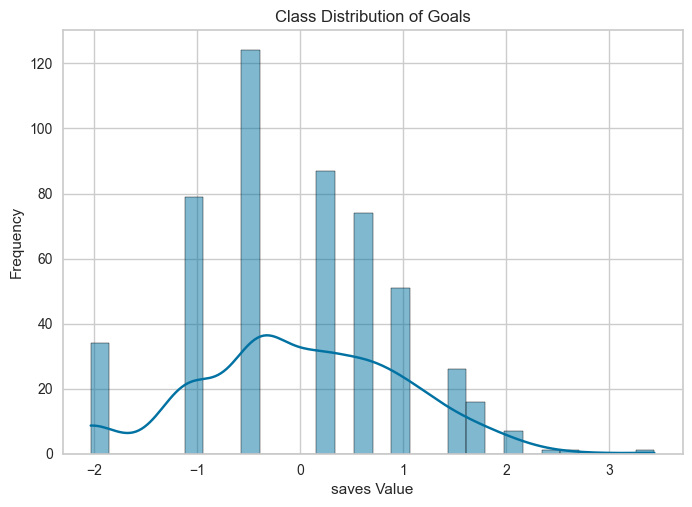

In [103]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[saves_features]
g_saves_data_tar = g_saves_data_tar[saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

print(g_saves_data['saves'].value_counts())

sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_saves = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_saves.fit(g_saves_data[['saves']])
joblib.dump(pt_gk_saves, './models/pt_gk_saves.pkl')  # Save fitted transformer

g_saves_data['saves'] = pt_gk_saves.transform(g_saves_data[['saves']])


sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1612
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 46
[LightGBM] [Info] Start training from score 0.001457
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Description,Value
0,Session id,5885
1,Target,saves
2,Target type,Regression
3,Original data shape,"(501, 75)"
4,Transformed data shape,"(501, 15)"
5,Transformed train set shape,"(400, 15)"
6,Transformed test set shape,"(101, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3085,0.1821,0.4158,0.8051,0.2038,0.6898,0.3810
et,Extra Trees Regressor,0.3087,0.1790,0.4121,0.8063,0.2028,0.6966,0.4130
gbr,Gradient Boosting Regressor,0.3139,0.1867,0.4214,0.7981,0.2034,0.7131,0.3430
lightgbm,Light Gradient Boosting Machine,0.3236,0.1967,0.4339,0.7893,0.2107,0.7435,0.7570
br,Bayesian Ridge,0.3299,0.2018,0.4382,0.7805,0.2092,0.7037,0.3110
en,Elastic Net,0.3300,0.2011,0.4390,0.7832,0.2096,0.6868,0.2900
xgboost,Extreme Gradient Boosting,0.3331,0.2140,0.4562,0.7714,0.2206,0.7546,0.3890
llar,Lasso Least Angle Regression,0.3368,0.2045,0.4438,0.7810,0.2132,0.6801,0.1900
lasso,Lasso Regression,0.3368,0.2045,0.4438,0.7810,0.2132,0.6801,0.4620
ridge,Ridge Regression,0.3374,0.2037,0.4412,0.7786,0.2134,0.7202,0.2050


RandomForestRegressor(n_jobs=-1, random_state=5885)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


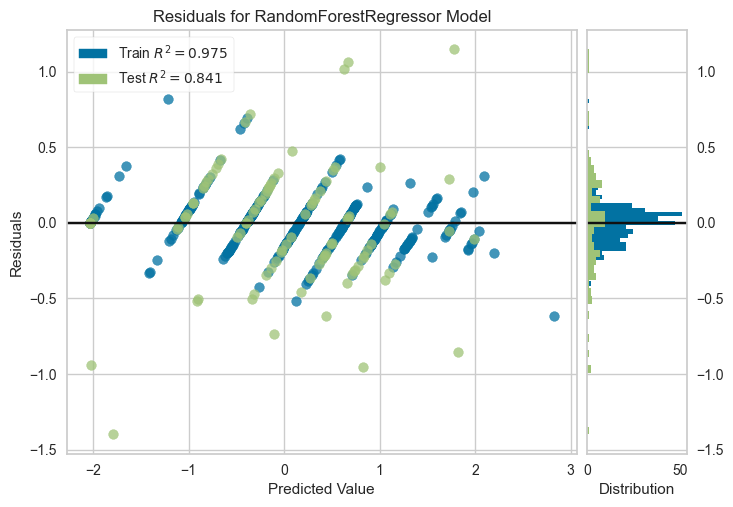

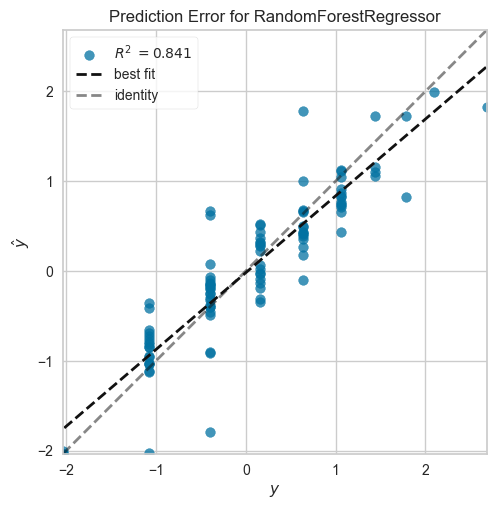

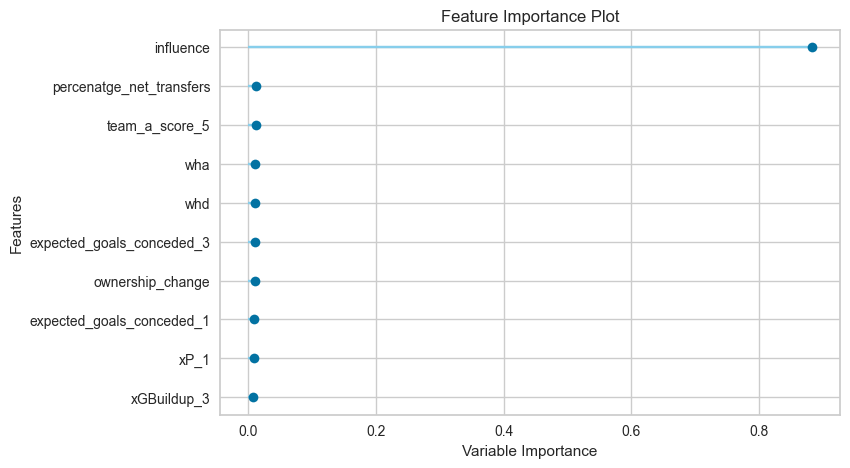

In [104]:
base_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_saves_best = base_g_saves_model.compare_models(sort='MAE', n_select=1)
print(base_g_saves_best)

print('Évaluate the model...')
evaluate_model(base_g_saves_best)

print('Plots...')
plot_model(base_g_saves_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_saves_best, plot='error')          # Prediction error plot
plot_model(base_g_saves_best, plot='feature')        # Feature importance

### Tune Model


In [105]:
g_saves_tuned = tune_model(base_g_saves_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2279,0.0900,0.3000,0.9261,0.1664,0.7322
1,0.2062,0.0602,0.2453,0.9326,0.1317,0.5565
2,0.3281,0.2259,0.4753,0.6920,0.1880,0.7301
3,0.3302,0.2168,0.4656,0.7758,0.2272,0.7831
4,0.3719,0.2296,0.4792,0.8149,0.2203,0.6661
5,0.2907,0.1612,0.4015,0.8290,0.1978,0.7029
6,0.3813,0.3292,0.5738,0.6352,0.2672,0.7472
7,0.2495,0.1115,0.3339,0.8444,0.1765,0.6436
8,0.3629,0.2160,0.4647,0.7640,0.2242,0.7852


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [106]:
g_saves_final_model = finalize_model(base_g_saves_best)
save_model(g_saves_final_model, './models/g_saves_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
 

# Goals Conceded


In [107]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


expected_goals_conceded
1.00    7
1.33    7
1.48    7
0.72    7
1.52    6
       ..
0.09    1
0.32    1
2.38    1
0.75    1
3.60    1
Name: count, Length: 234, dtype: int64


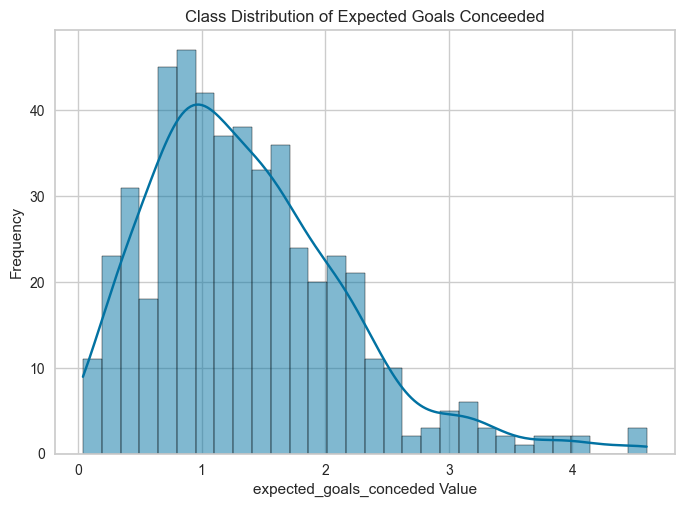

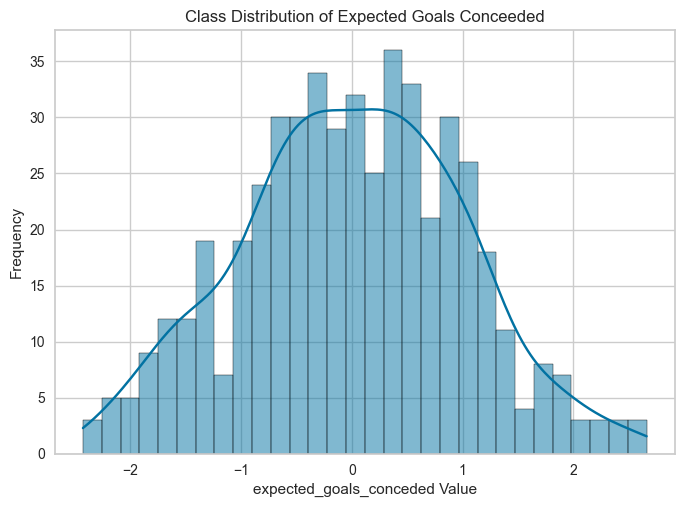

In [108]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[xgc_features]
g_xgc_data_tar = g_xgc_data_tar[xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(g_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_xgc.fit(g_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_gk_xgc, './models/pt_gk_xgc.pkl')  # Save fitted transformer

g_xgc_data['expected_goals_conceded'] = pt_gk_xgc.transform(g_xgc_data[['expected_goals_conceded']])


sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1604
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 46
[LightGBM] [Info] Start training from score 0.003764
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Description,Value
0,Session id,2875
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(501, 70)"
4,Transformed data shape,"(501, 14)"
5,Transformed train set shape,"(400, 14)"
6,Transformed test set shape,"(101, 14)"
7,Numeric features,68
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,0.7323,0.8309,0.9092,0.1397,0.4286,1.7305,0.3190
en,Elastic Net,0.7338,0.8329,0.9104,0.1379,0.4387,1.7211,0.3900
lasso,Lasso Regression,0.7371,0.8368,0.9125,0.1343,0.4497,1.6581,0.1760
llar,Lasso Least Angle Regression,0.7371,0.8368,0.9125,0.1343,0.4497,1.6581,0.5310
huber,Huber Regressor,0.7398,0.8525,0.9214,0.1181,0.4600,1.4896,0.4840
ridge,Ridge Regression,0.7431,0.8456,0.9178,0.1225,0.4238,1.7943,0.1150
lr,Linear Regression,0.7459,0.8524,0.9215,0.1153,0.4233,1.7894,0.1630
ada,AdaBoost Regressor,0.7532,0.8700,0.9304,0.1008,0.4400,1.7799,0.4950
et,Extra Trees Regressor,0.7545,0.8700,0.9297,0.1000,0.4278,2.1080,0.4850
rf,Random Forest Regressor,0.7557,0.8664,0.9288,0.0996,0.4265,2.1182,0.6620


BayesianRidge()
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


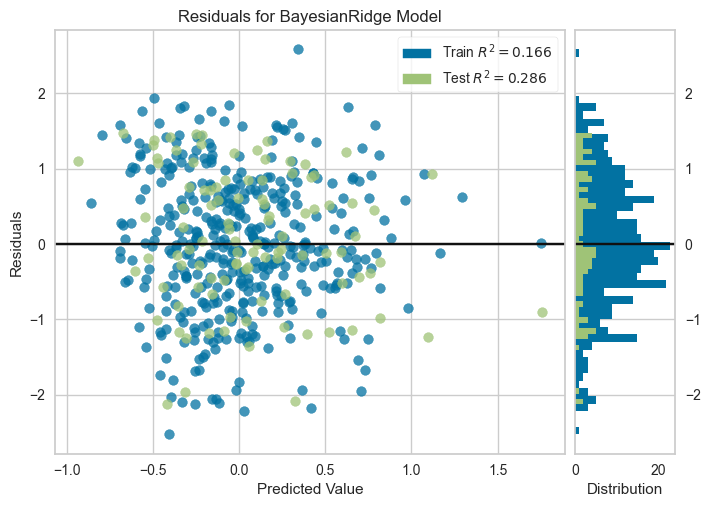

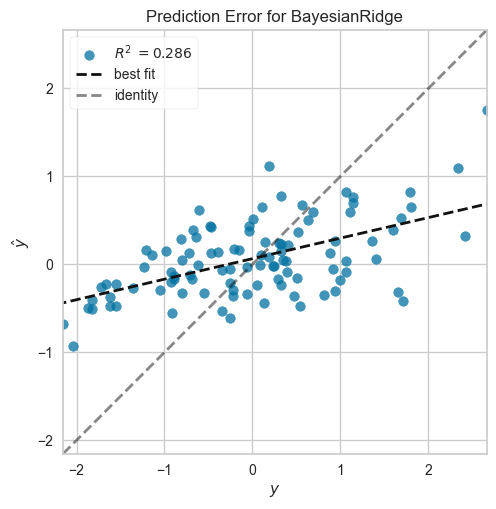

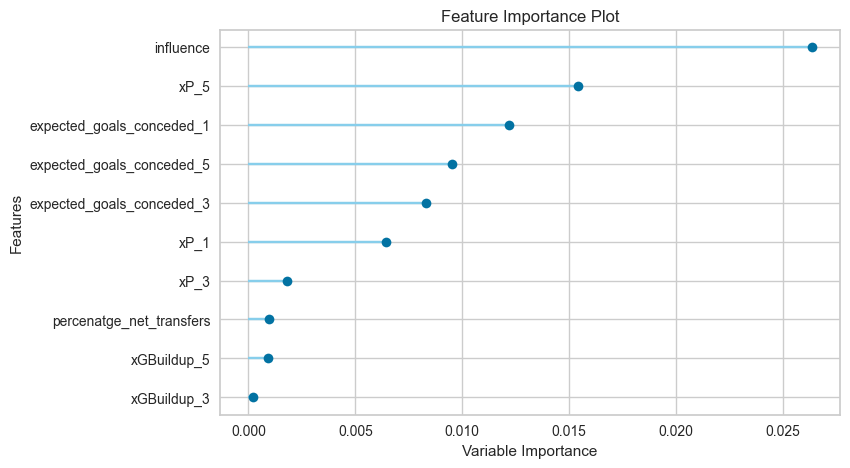

In [109]:
base_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

print('Évaluate the model...')
evaluate_model(base_g_xgc_best)

print('Plots...')
plot_model(base_g_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_xgc_best, plot='error')          # Prediction error plot
plot_model(base_g_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [110]:
g_xgc_tuned = tune_model(base_g_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7665,0.8222,0.9068,0.1336,0.4551,1.9359
1,0.7539,1.0029,1.0015,0.0898,0.4291,1.0067
2,0.7444,0.7758,0.8808,0.2136,0.4359,1.5729
3,0.6738,0.7108,0.8431,0.2132,0.4314,1.7863
4,0.5894,0.6295,0.7934,0.2077,0.3444,1.9228
5,0.8572,1.0121,1.0060,0.0276,0.4788,1.7517
6,0.6899,0.7862,0.8867,0.0502,0.3978,0.9000
7,0.7213,0.7620,0.8729,0.1863,0.4373,1.1430
8,0.7459,0.8863,0.9414,0.0515,0.3931,1.1670


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [111]:
g_xgc_final_model = finalize_model(g_xgc_tuned)
save_model(g_xgc_final_model, './models/g_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                 ('remove_multicollinearity',
                  TransformerWrapper(exclude=[],
                                     transfo

## Def


expected_goals_conceded
0.72    28
0.83    23
1.48    23
0.00    23
0.91    21
        ..
4.11     1
2.66     1
2.71     1
0.08     1
2.78     1
Name: count, Length: 292, dtype: int64


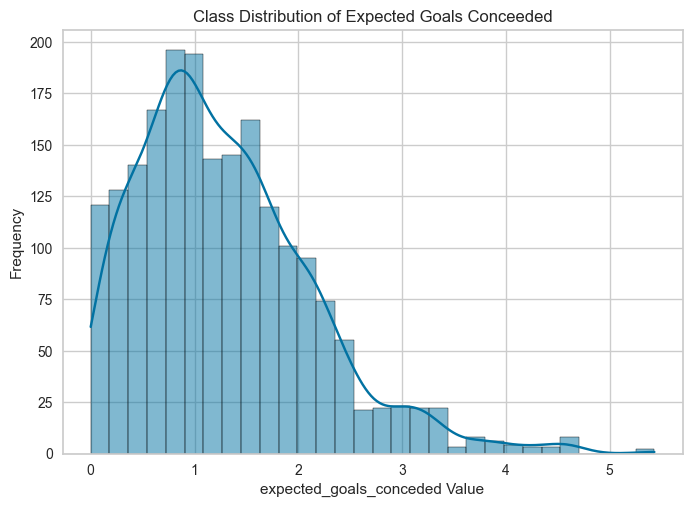

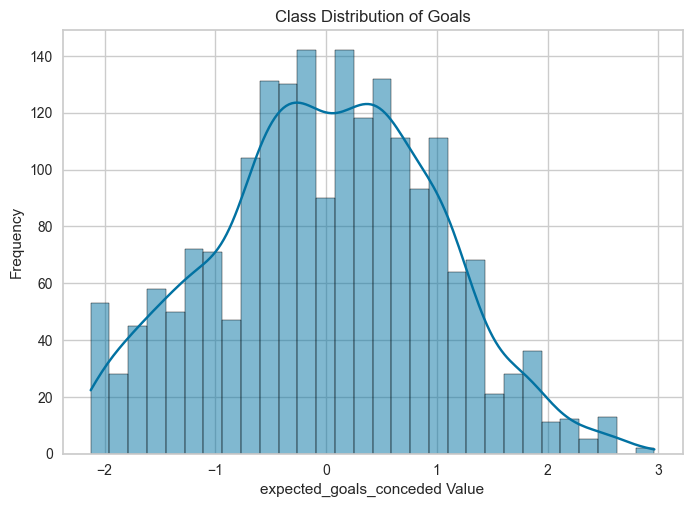

In [112]:
def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[xgc_features]
def_xgc_data_tar = def_xgc_data_tar[xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(def_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xgc.fit(def_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_def_xgc, './models/pt_def_xgc.pkl')  # Save fitted transformer

def_xgc_data['expected_goals_conceded'] = pt_def_xgc.transform(def_xgc_data[['expected_goals_conceded']])


sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Goals')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5312
[LightGBM] [Info] Number of data points in the train set: 1590, number of used features: 57
[LightGBM] [Info] Start training from score 0.001988


,Description,Value
0,Session id,2108
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1988, 70)"
4,Transformed data shape,"(1988, 14)"
5,Transformed train set shape,"(1590, 14)"
6,Transformed test set shape,"(398, 14)"
7,Numeric features,68
8,Rows with missing values,0.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.6687,0.7270,0.8511,0.2678,0.3874,1.5317,0.9370
xgboost,Extreme Gradient Boosting,0.6744,0.7382,0.8581,0.2561,0.3839,1.6199,0.9030
et,Extra Trees Regressor,0.6788,0.7149,0.8439,0.2798,0.4181,1.3415,0.9520
rf,Random Forest Regressor,0.6907,0.7409,0.8596,0.2529,0.4230,1.3340,1.2720
gbr,Gradient Boosting Regressor,0.7187,0.7988,0.8927,0.1941,0.4291,1.4606,0.8520
ada,AdaBoost Regressor,0.7529,0.8475,0.9199,0.1450,0.4725,1.3517,1.2680
lr,Linear Regression,0.7783,0.9197,0.9581,0.0728,0.4745,1.3087,0.9080
ridge,Ridge Regression,0.7786,0.9195,0.9580,0.0731,0.4745,1.3116,0.3630
br,Bayesian Ridge,0.7800,0.9198,0.9582,0.0729,0.4854,1.2740,0.6020
en,Elastic Net,0.7966,0.9575,0.9779,0.0346,0.5336,1.1188,0.3850


LGBMRegressor(n_jobs=-1, random_state=2108)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


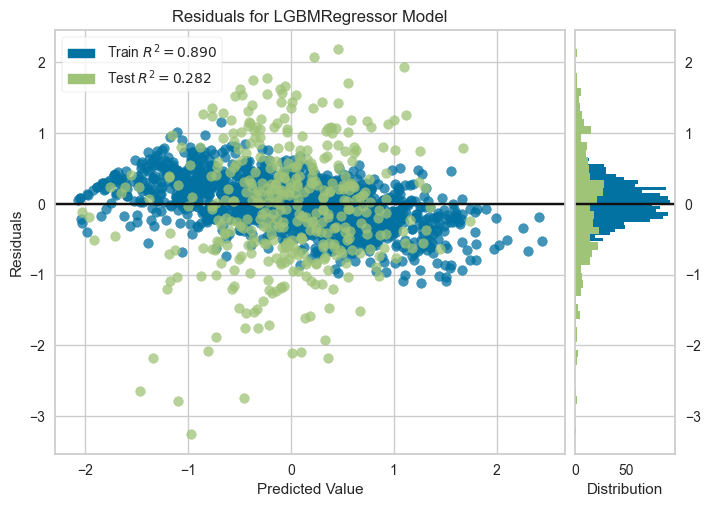

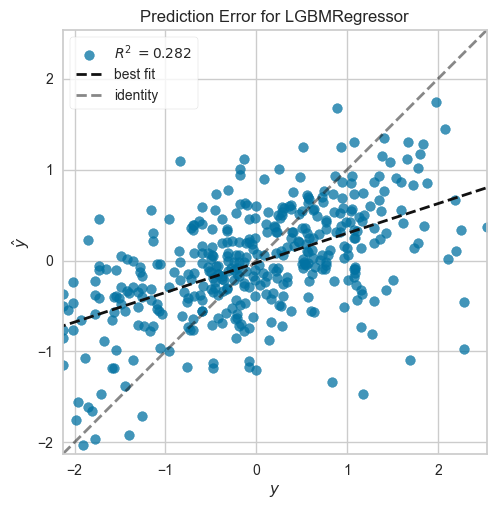

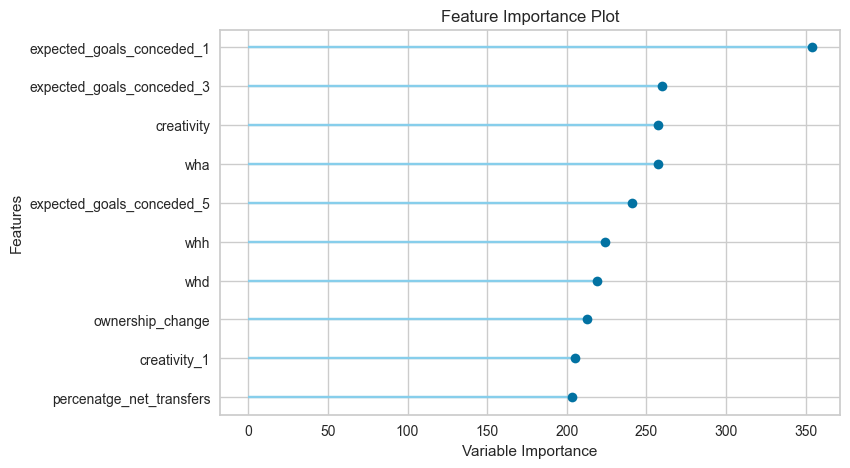

In [113]:
base_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xgc_best = base_def_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_def_xgc_best)

print('Évaluate the model...')
evaluate_model(base_def_xgc_best)

print('Plots...')
plot_model(base_def_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xgc_best, plot='error')          # Prediction error plot
plot_model(base_def_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [114]:
def_xgc_tuned = tune_model(base_def_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6816,0.7577,0.8705,0.1811,0.3965,1.4715
1,0.6400,0.6457,0.8036,0.3211,0.3737,1.9300
2,0.5957,0.5803,0.7618,0.3831,0.3587,1.2928
3,0.7908,0.9379,0.9685,0.1438,0.4381,1.3509
4,0.7482,0.8332,0.9128,0.1670,0.4064,2.2058
5,0.6764,0.7537,0.8682,0.2291,0.3932,1.4163
6,0.7563,0.8971,0.9472,0.1373,0.4152,1.9193
7,0.7205,0.8056,0.8976,0.2125,0.4047,1.7132
8,0.6714,0.6871,0.8289,0.3144,0.3762,2.7840


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [115]:
def_xgc_final_model = finalize_model(base_def_xgc_best)
save_model(def_xgc_final_model, './models/def_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

In [116]:
pd.read_csv('./data/2022-23/players/Aaron_Cresswell_457/gw.csv')

,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards
0,0,0,16,0,18.7,457,0.10,0.10,0.00,2.23,...,2,0,0.0,1,0,0,0,50,True,0
1,0,0,14,0,65.8,457,0.21,0.26,0.05,1.36,...,0,1,1.0,2,21509,45044,23535,50,False,0
2,0,0,6,0,38.8,457,0.33,0.38,0.05,1.71,...,2,0,18.0,0,-19414,20572,39986,50,True,1
3,0,0,26,1,5.8,457,0.01,0.06,0.05,0.49,...,1,0,8.0,6,-53162,5437,58599,50,False,0
4,0,0,16,0,1.5,457,0.01,0.01,0.00,0.44,...,1,1,0.0,2,-21500,5184,26684,49,True,0
5,0,0,0,0,0.0,457,0.00,0.00,0.00,0.00,...,1,2,0.0,0,-33385,5180,38565,49,False,0
6,0,0,13,0,31.8,457,0.09,0.13,0.04,0.36,...,0,1,10.0,2,6734,17465,10731,48,False,0
7,0,0,21,1,12.1,457,0.01,0.01,0.00,0.74,...,0,2,0.0,5,17709,30963,13254,48,True,1
8,0,0,20,0,42.8,457,0.12,0.12,0.00,0.70,...,1,3,2.0,2,39911,49989,10078,48,True,0
9,0,1,19,0,47.9,457,0.36,0.36,0.00,0.45,...,1,1,2.0,3,16237,27263,11026,48,False,0
